# Italy/Rome — Viral Tourism Panel Dataset
**First database build** — Eurostat hotel nights + Wikipedia pageviews + Google Trends (2015–2024)

Key question: do online attention signals lead actual tourist arrivals?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings; warnings.filterwarnings("ignore")

panel = pd.read_csv("data/panel_italy.csv", parse_dates=["date"])
print(f"Shape: {panel.shape}")
panel.describe().round(0)

Shape: (133, 8)


,date,tourist_nights,wiki_italy,wiki_rome,wiki_tourism_italy,trend_italy_tourism,trend_visit_rome
count,133,133.0,114.0,114.0,114.0,120.0,120.0
mean,2020-07-01 07:34:44.210526208,20850974.0,402895.0,185267.0,8018.0,45.0,62.0
min,2015-01-01 00:00:00,596806.0,10281.0,6046.0,205.0,24.0,14.0
25%,2017-10-01 00:00:00,12975556.0,331606.0,160491.0,6320.0,36.0,54.0
50%,2020-07-01 00:00:00,17244221.0,360294.0,178904.0,7490.0,42.0,65.0
75%,2023-04-01 00:00:00,29699317.0,434975.0,193244.0,9366.0,50.0,76.0
max,2026-01-01 00:00:00,46610828.0,1526421.0,574433.0,15541.0,100.0,100.0
std,NaN,12120534.0,152088.0,52591.0,2316.0,14.0,22.0


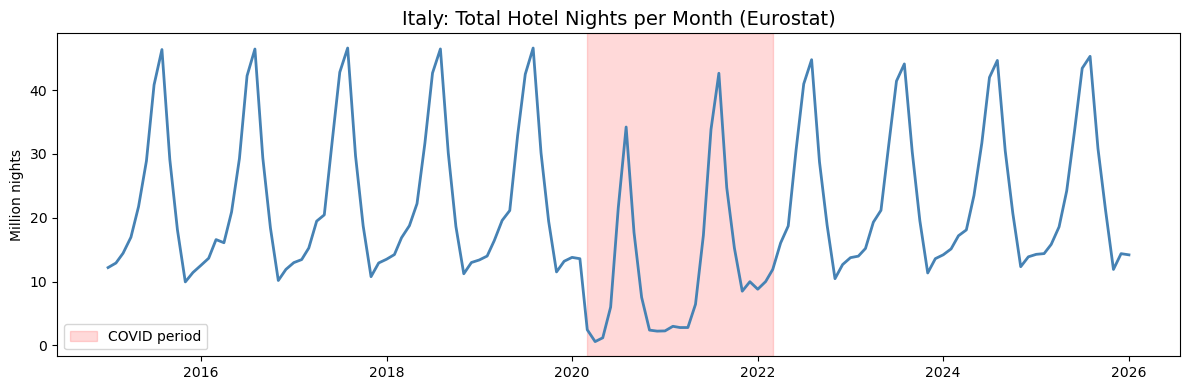

In [2]:
# Tourist nights — the dependent variable
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(panel["date"], panel["tourist_nights"] / 1e6, color="steelblue", linewidth=2)
ax.axvspan(pd.Timestamp("2020-03"), pd.Timestamp("2022-03"), alpha=0.15, color="red", label="COVID period")
ax.set_title("Italy: Total Hotel Nights per Month (Eurostat)", fontsize=14)
ax.set_ylabel("Million nights")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(); plt.tight_layout(); plt.show()

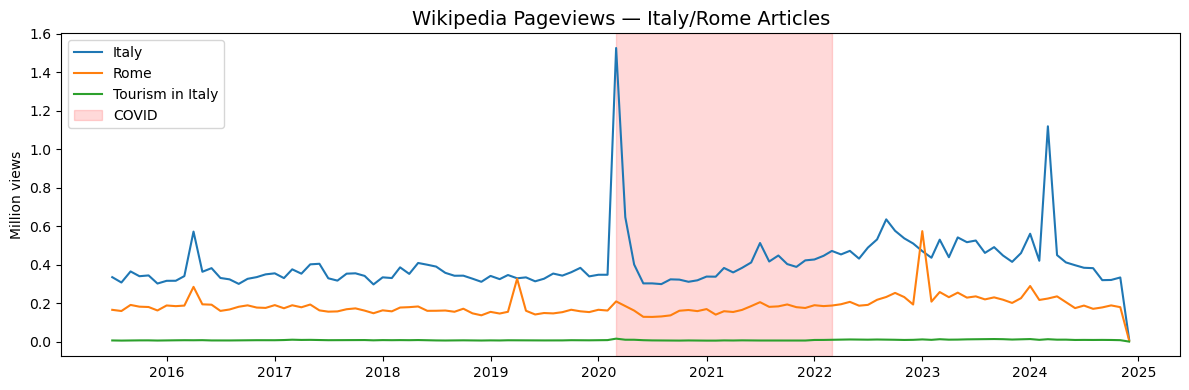

In [3]:
# Wikipedia pageviews — attention signals
fig, ax = plt.subplots(figsize=(12, 4))
for col, label, color in [("wiki_italy", "Italy", "steelblue"), ("wiki_rome", "Rome", "darkorange"), ("wiki_tourism_italy", "Tourism in Italy", "green")]:
    ax.plot(panel["date"], panel[col] / 1e6, label=label, linewidth=1.5)
ax.axvspan(pd.Timestamp("2020-03"), pd.Timestamp("2022-03"), alpha=0.15, color="red", label="COVID")
ax.set_title("Wikipedia Pageviews — Italy/Rome Articles", fontsize=14)
ax.set_ylabel("Million views")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(); plt.tight_layout(); plt.show()

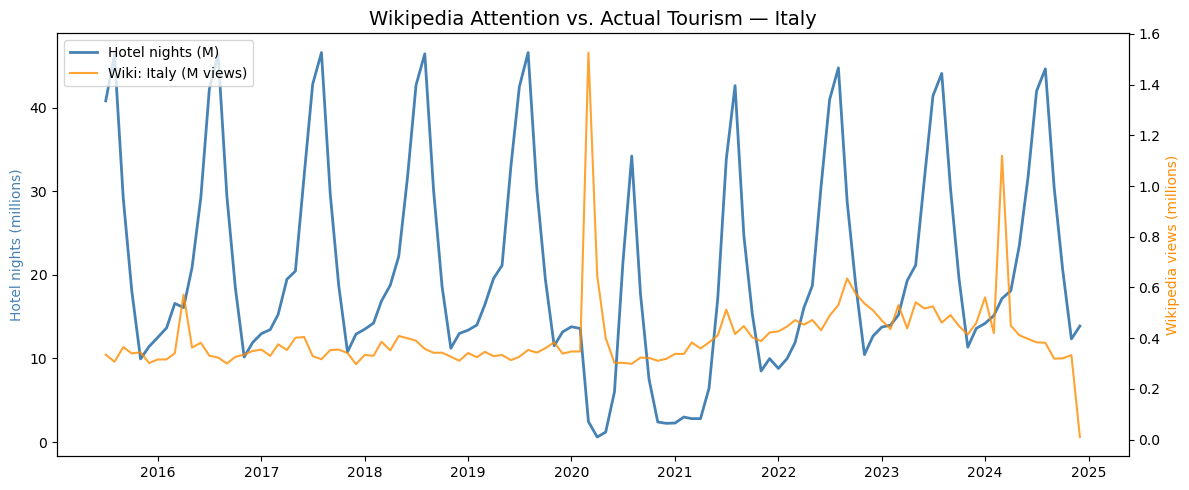

In [4]:
# Dual-axis: attention signal vs actual arrivals
df = panel.dropna(subset=["wiki_italy", "tourist_nights"])
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(df["date"], df["tourist_nights"] / 1e6, color="steelblue", linewidth=2, label="Hotel nights (M)")
ax2.plot(df["date"], df["wiki_italy"] / 1e6, color="darkorange", linewidth=1.5, alpha=0.8, label="Wiki: Italy (M views)")
ax1.set_ylabel("Hotel nights (millions)", color="steelblue")
ax2.set_ylabel("Wikipedia views (millions)", color="darkorange")
ax1.set_title("Wikipedia Attention vs. Actual Tourism — Italy", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

Correlation matrix:
                     tourist_nights  wiki_italy  wiki_rome  \
tourist_nights                 1.00       -0.09      -0.03   
wiki_italy                    -0.09        1.00       0.39   
wiki_rome                     -0.03        0.39       1.00   
wiki_tourism_italy             0.02        0.67       0.57   
trend_italy_tourism           -0.08        0.09      -0.16   
trend_visit_rome               0.46        0.04       0.29   

                     wiki_tourism_italy  trend_italy_tourism  trend_visit_rome  
tourist_nights                     0.02                -0.08              0.46  
wiki_italy                         0.67                 0.09              0.04  
wiki_rome                          0.57                -0.16              0.29  
wiki_tourism_italy                 1.00                -0.11              0.41  
trend_italy_tourism               -0.11                 1.00             -0.32  
trend_visit_rome                   0.41                -0.3

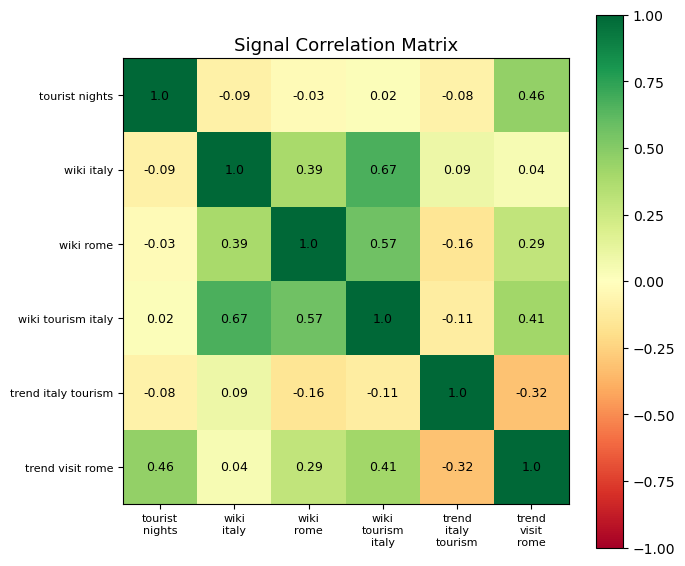

In [5]:
# Correlation matrix — are signals correlated with actual arrivals?
cols = ["tourist_nights", "wiki_italy", "wiki_rome", "wiki_tourism_italy", "trend_italy_tourism", "trend_visit_rome"]
corr = panel[cols].corr().round(2)
print("Correlation matrix:")
print(corr)

import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(cols))); ax.set_xticklabels([c.replace("_", "\n") for c in cols], fontsize=8)
ax.set_yticks(range(len(cols))); ax.set_yticklabels([c.replace("_", " ") for c in cols], fontsize=8)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, str(corr.iloc[i, j]), ha="center", va="center", fontsize=9)
ax.set_title("Signal Correlation Matrix", fontsize=13)
plt.tight_layout(); plt.show()